In [1]:
# Data collection command:
# `python comet_download.py --project=ns-autostep-feature-search-hyper-sweep --n_threads=8`

In [2]:
from collections import defaultdict
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from phd.feature_search.analysis.analysis_utils import *
from phd.feature_search.analysis.plotting import plot_learning_curves, plot_param_sensitivity

sns.set_theme('notebook', 'white')
%matplotlib inline

## Load Data

In [ ]:
save_path = 'figures/'
config_data_path = 'data/ns-autostep-feature-search-hyper-sweep_params.csv'
run_data_path = 'data/ns-autostep-feature-search-hyper-sweep_metrics.csv'

config_dfs, run_dfs = load_experiment_data(config_data_path, run_data_path)
del config_dfs[np.nan], run_dfs[np.nan]

config_dfs['weight_decay_sweep']['optimizer.weight_decay'] = config_dfs['weight_decay_sweep']['optimizer|weight_decay'].apply(
    lambda x: f'2^{np.log2(x)}' if x > 0 else '0')

{k: len(v) for k, v in config_dfs.items()}

/home/edan/local_projects/phd_research/phd/feature_search/analysis/analysis_utils.py:290: DtypeWarning: Columns (27) have mixed types. Specify dtype option on import or set low_memory=False.
  all_sweeps_config_df = pd.read_csv(config_data_path, index_col=0)


{'perfect_features_baseline_sweep': 125,
 'baseline_hyper_sweep': 2000,
 'maturity_threshold_hyper_sweep': 3594,
 'maturity_threshold_hyper_sweep_v2': 300,
 'adaptive_init_lr_hyper_sweep': 200,
 'scaling_hyper_sweep': 175,
 'weight_decay_sweep': 80}

In [23]:
print("_____Best Hyperparameter Configurations_____")
split_vars = defaultdict(list)
split_vars['adaptive_init_lr_hyper_sweep'] = ['feature_recycling|initial_step_size_method']
split_vars['scaling_hyper_sweep'] = ['model.hidden_dim']
best_config_dfs, best_run_dfs = get_best_ablation_values(
    config_dfs, run_dfs, sweep_split_vars=split_vars)
{k: len(v) for k, v in best_config_dfs.items()}

_____Best Hyperparameter Configurations_____
perfect_features_baseline_sweep ['optimizer.learning_rate', 'optimizer.meta_learning_rate'] []

=== perfect_features_baseline_sweep ===

Configuration: (no split vars)
  Best optimizer.learning_rate=${eval:2**-6}
  Best optimizer.meta_learning_rate=${eval:2**-9}

baseline_hyper_sweep ['optimizer.learning_rate', 'model.hidden_dim', 'feature_recycling.recycle_rate', 'feature_recycling.utility_decay', 'optimizer.meta_learning_rate'] []

=== baseline_hyper_sweep ===

Configuration: (no split vars)
  Best optimizer.learning_rate=${eval:2**-14}
  Best model.hidden_dim=5120.0
  Best feature_recycling.recycle_rate=0.001
  Best feature_recycling.utility_decay=0.99
  Best optimizer.meta_learning_rate=${eval:2**-9}

maturity_threshold_hyper_sweep ['feature_recycling.feature_protection_steps', 'optimizer.learning_rate', 'feature_recycling.recycle_rate', 'feature_recycling.utility_decay', 'optimizer.meta_learning_rate'] []

=== maturity_threshold_hyper_s

{'perfect_features_baseline_sweep': 5,
 'baseline_hyper_sweep': 1,
 'maturity_threshold_hyper_sweep': 5,
 'maturity_threshold_hyper_sweep_v2': 5,
 'adaptive_init_lr_hyper_sweep': 10,
 'scaling_hyper_sweep': 25,
 'weight_decay_sweep': 10}

In [24]:
print("_____Best Hyperparameter Configurations_____")
split_vars = defaultdict(list)
split_vars['adaptive_init_lr_hyper_sweep'] = ['feature_recycling|initial_step_size_method']
split_vars['scaling_hyper_sweep'] = ['model.hidden_dim']
best_feat_config_dfs, best_feat_run_dfs = get_best_ablation_values(
    config_dfs, run_dfs, sweep_split_vars=split_vars,
    metric_col='feature_match/perfect_match_count', metric_direction='max',
)
{k: len(v) for k, v in best_feat_config_dfs.items()}

_____Best Hyperparameter Configurations_____
perfect_features_baseline_sweep ['optimizer.learning_rate', 'optimizer.meta_learning_rate'] []

=== perfect_features_baseline_sweep ===

Configuration: (no split vars)
  Best optimizer.learning_rate=${eval:2**-3}
  Best optimizer.meta_learning_rate=${eval:2**-11}

baseline_hyper_sweep ['optimizer.learning_rate', 'model.hidden_dim', 'feature_recycling.recycle_rate', 'feature_recycling.utility_decay', 'optimizer.meta_learning_rate'] []

=== baseline_hyper_sweep ===

Configuration: (no split vars)
  Best optimizer.learning_rate=${eval:2**-14}
  Best model.hidden_dim=5120
  Best feature_recycling.recycle_rate=0.0005
  Best feature_recycling.utility_decay=0.99999
  Best optimizer.meta_learning_rate=${eval:2**-7}

maturity_threshold_hyper_sweep ['feature_recycling.feature_protection_steps', 'optimizer.learning_rate', 'feature_recycling.recycle_rate', 'feature_recycling.utility_decay', 'optimizer.meta_learning_rate'] []

=== maturity_threshold_hype

{'perfect_features_baseline_sweep': 5,
 'baseline_hyper_sweep': 3,
 'maturity_threshold_hyper_sweep': 5,
 'maturity_threshold_hyper_sweep_v2': 5,
 'adaptive_init_lr_hyper_sweep': 10,
 'scaling_hyper_sweep': 25,
 'weight_decay_sweep': 10}

## Comparison

### Best hyperparams for loss

['Perfect Features Baseline' 'Median Utility Reset'
 'With Maturity Threshold' 'With Maturity Threshold v2'
 'Adaptive Initial Step-Size']


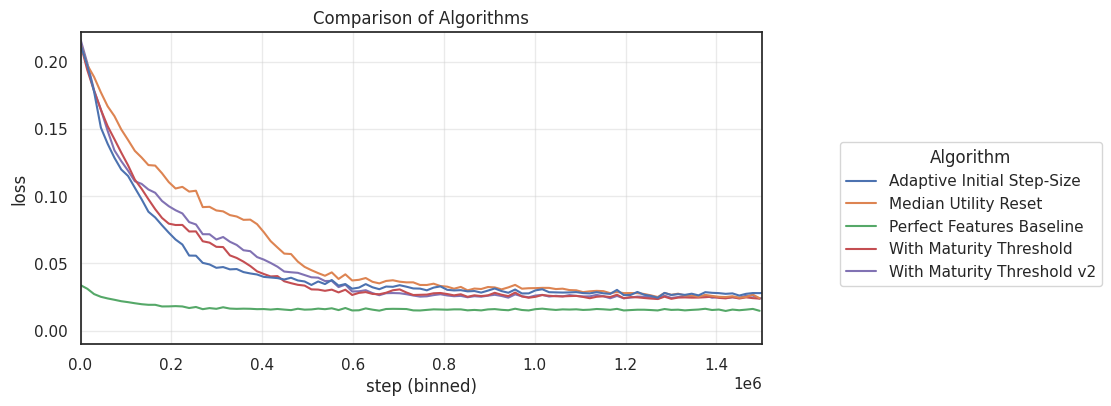

['Perfect Features Baseline' 'Median Utility Reset'
 'With Maturity Threshold' 'With Maturity Threshold v2'
 'Adaptive Initial Step-Size']


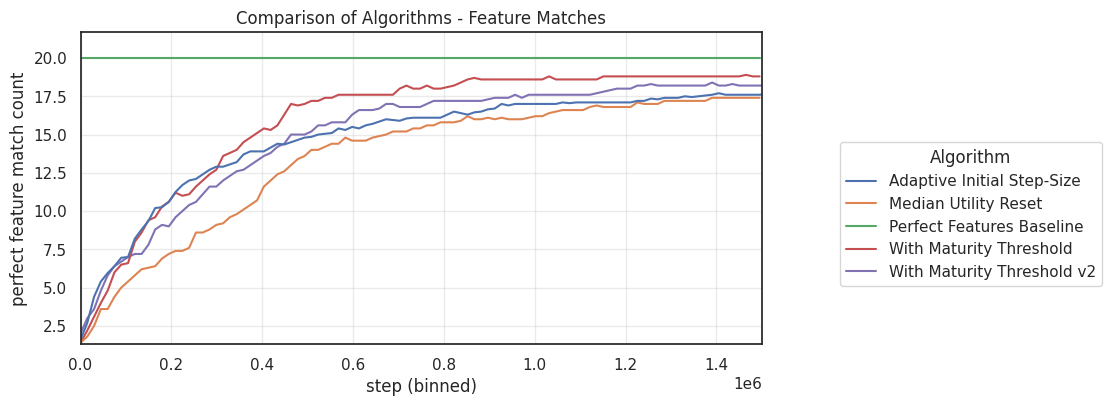

In [38]:
combined_run_df = pd.concat(list(best_run_dfs.values()))
combined_config_df = pd.concat(list(best_config_dfs.values()))

algo_map = {
    'baseline_hyper_sweep': 'Median Utility Reset',
    'maturity_threshold_hyper_sweep': 'With Maturity Threshold',
    'maturity_threshold_hyper_sweep_v2': 'With Maturity Threshold v2',
    'adaptive_init_lr_hyper_sweep': 'Adaptive Initial Step-Size',
    'perfect_features_baseline_sweep': 'Perfect Features Baseline',
}

# Only keep rows whose sweep_name is in algo_map
combined_config_df = combined_config_df[combined_config_df['sweep_name'].isin(algo_map.keys())].copy()
valid_run_ids = combined_config_df['run_id'].unique()
combined_run_df = combined_run_df[combined_run_df['run_id'].isin(valid_run_ids)].copy()
combined_config_df['algo'] = combined_config_df['sweep_name'].map(algo_map)


plot_learning_curves(
    run_df = combined_run_df,
    config_df = combined_config_df,
    n_bins = 200,
    figsize = (8, 4),
    hue_col = 'algo',
    legend_title = 'Algorithm',
)
plt.xlim(0, 1_500_000)
plt.title('Comparison of Algorithms')
plt.show()

plot_learning_curves(
    run_df = combined_run_df,
    config_df = combined_config_df,
    n_bins = 200,
    figsize = (8, 4),
    y_col = 'feature_match/perfect_match_count',
    y_label = 'perfect feature match count',
    hue_col = 'algo',
    legend_title = 'Algorithm',
)
plt.xlim(0, 1_500_000)
plt.title('Comparison of Algorithms - Feature Matches')
plt.show()

### Best hyperparams for feature matches

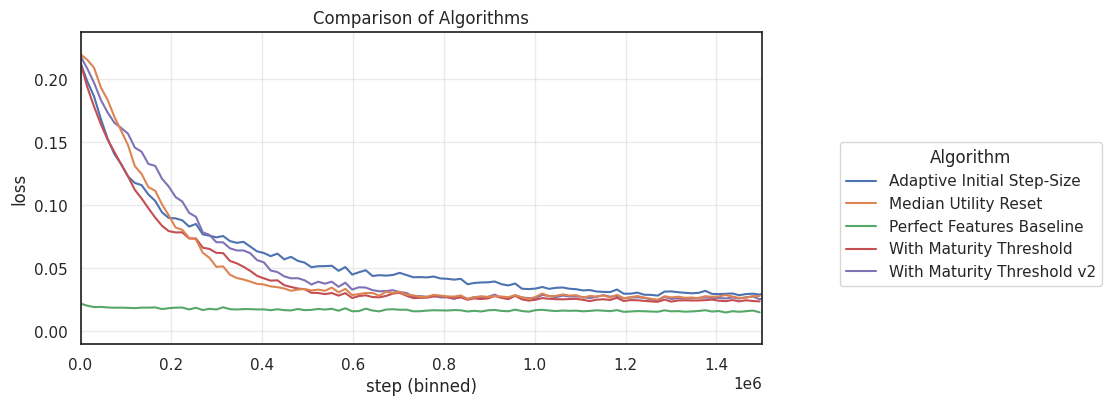

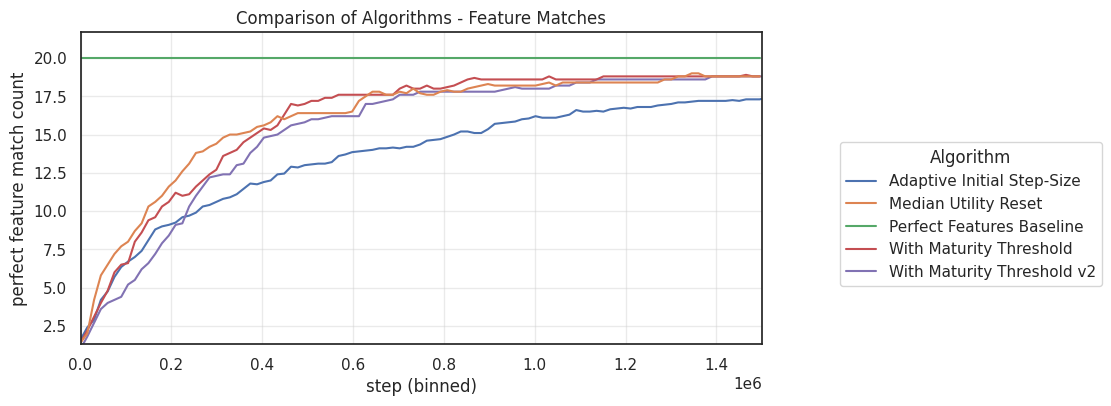

In [10]:
combined_feat_run_df = pd.concat(list(best_feat_run_dfs.values()))
combined_feat_config_df = pd.concat(list(best_feat_config_dfs.values()))

algo_map = {
    'baseline_hyper_sweep': 'Median Utility Reset',
    'maturity_threshold_hyper_sweep': 'With Maturity Threshold',
    'maturity_threshold_hyper_sweep_v2': 'With Maturity Threshold v2',
    'adaptive_init_lr_hyper_sweep': 'Adaptive Initial Step-Size',
    'perfect_features_baseline_sweep': 'Perfect Features Baseline'
}
combined_feat_config_df['algo'] = combined_feat_config_df['sweep_name'].map(algo_map)

plot_learning_curves(
    run_df = combined_feat_run_df,
    config_df = combined_feat_config_df,
    n_bins = 200,
    figsize = (8, 4),
    hue_col = 'algo',
    legend_title = 'Algorithm',
)
plt.xlim(0, 1_500_000)
plt.title('Comparison of Algorithms')
plt.show()

plot_learning_curves(
    run_df = combined_feat_run_df,
    config_df = combined_feat_config_df,
    n_bins = 200,
    figsize = (8, 4),
    y_col = 'feature_match/perfect_match_count',
    y_label = 'perfect feature match count',
    hue_col = 'algo',
    legend_title = 'Algorithm',
)
plt.xlim(0, 1_500_000)
plt.title('Comparison of Algorithms - Feature Matches')
plt.show()

## Baseline Performance & Hyperparam Sensitivity

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


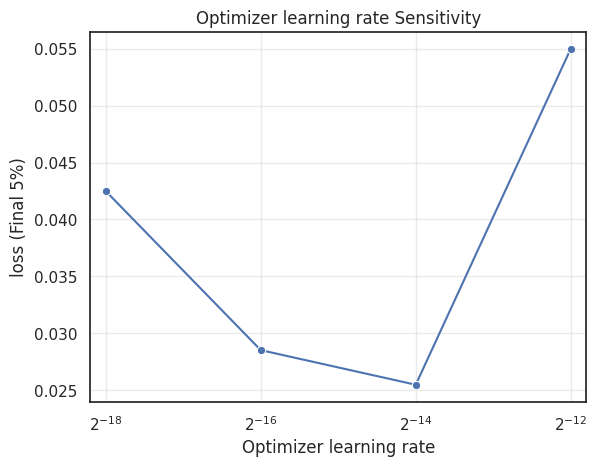

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


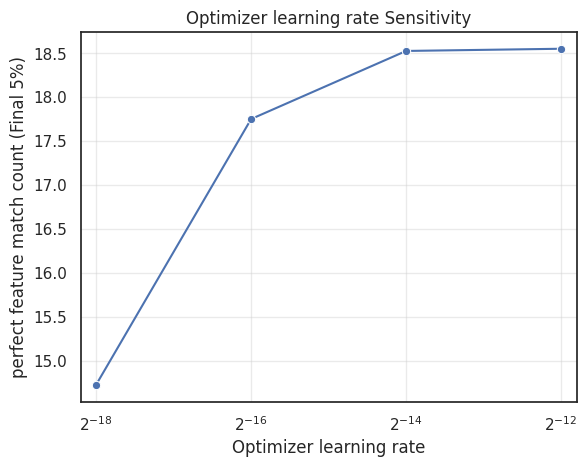

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


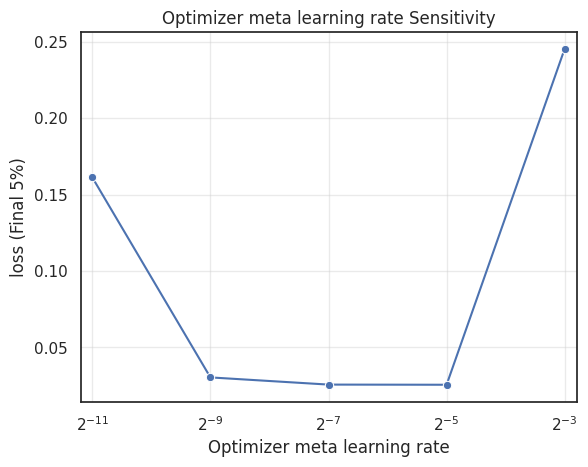

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


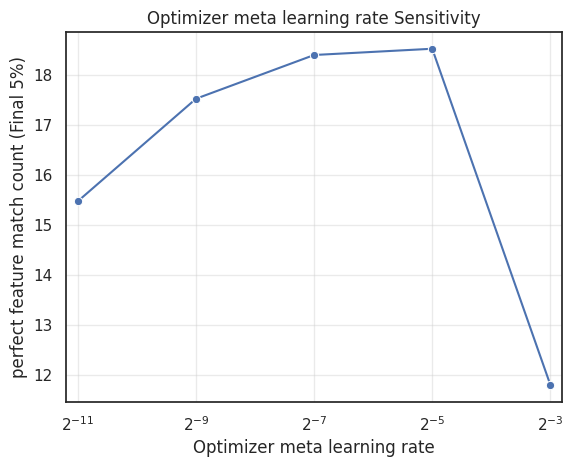

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


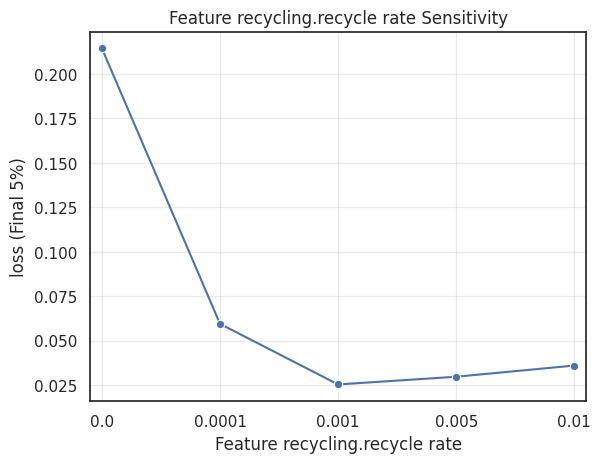

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


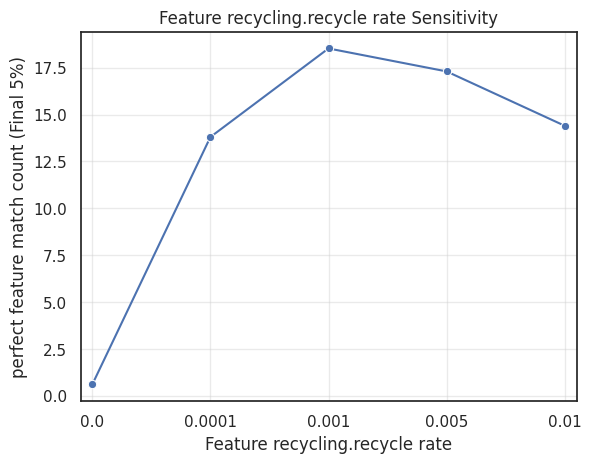

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


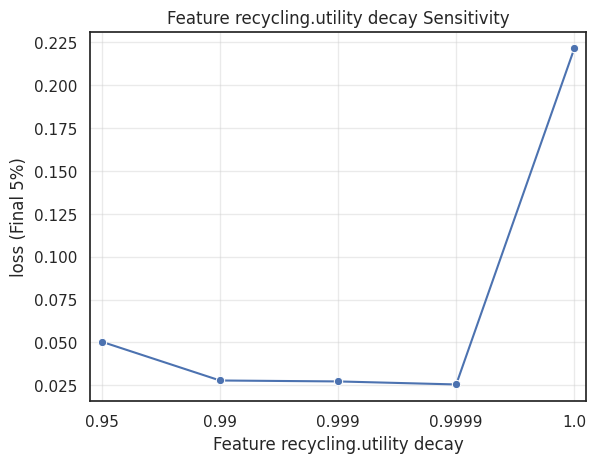

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


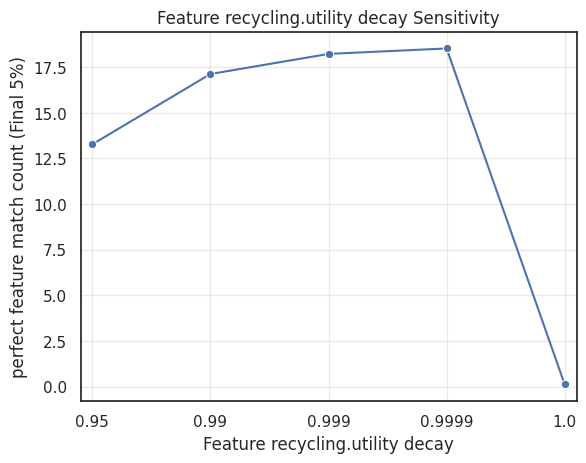

In [12]:
default_hyperparams = {
    'optimizer|learning_rate': 2**-14,
    'optimizer|meta_learning_rate': 2**-5,
    'feature_recycling.recycle_rate': 0.001,
    'feature_recycling.utility_decay': 0.9999,
}

for param_name, param_value in default_hyperparams.items():
    selected_run_df, selected_config_df = select_experiment_runs(
        run_df = run_dfs['baseline_hyper_sweep'],
        config_df = config_dfs['baseline_hyper_sweep'],
        chosen_values = {
            k: v for k, v in default_hyperparams.items()
            if k != param_name
        },
    )
    
    param_label = param_name.replace('|', ' ').replace('_', ' ').capitalize()
    
    for metric_col, metric_name in [('loss', 'loss'), ('feature_match/perfect_match_count', 'perfect feature match count')]:
        plot_param_sensitivity(
                run_df = selected_run_df,
                config_df = selected_config_df,
                x_col = param_name,
                title = f'{param_label} Sensitivity',
                x_label = param_label,
                y_label = metric_name,
                metric_col = metric_col,
                metric_type = 'final_avg', # {'cumulative', 'final_avg', 'last'}
                step_col = 'step',
                legend_title = None,
                show_ci = False,
                baseline_col = None,
                pow_2_x_axis = 'learning_rate' in param_name,
                pow_2_legend = True,
            )
        plt.show()

## With Maturity Threshold

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


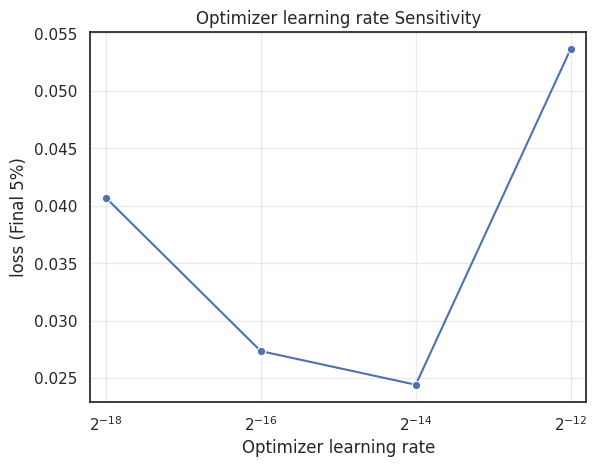

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


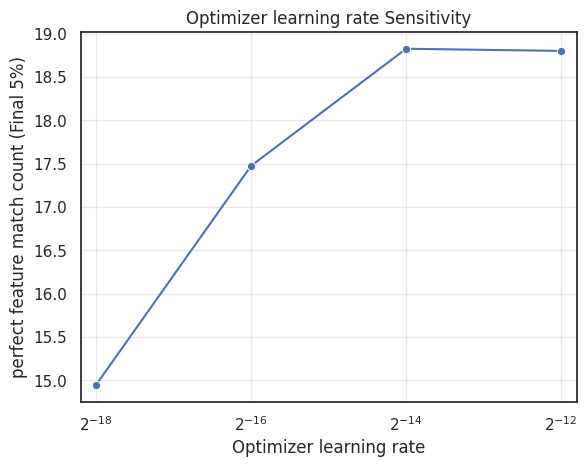

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


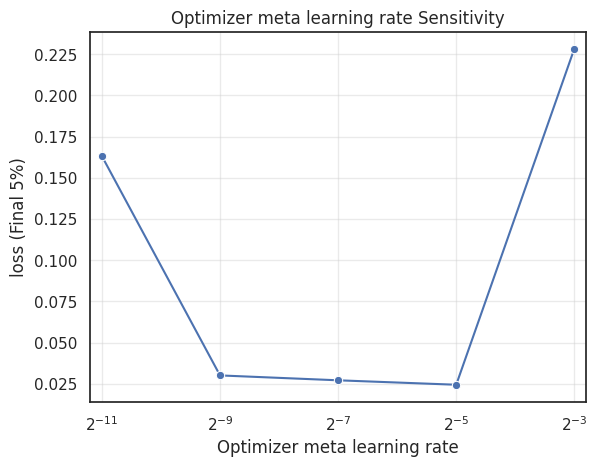

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


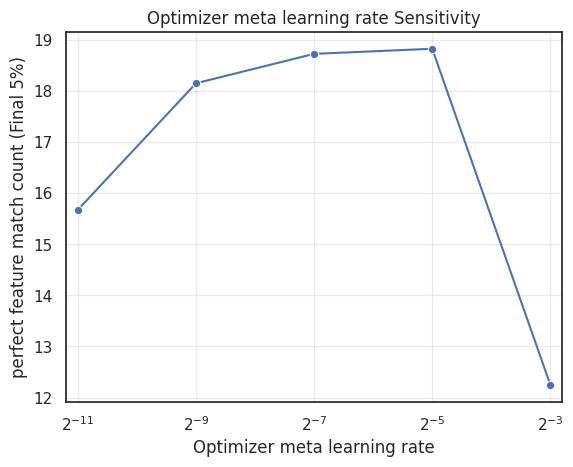

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


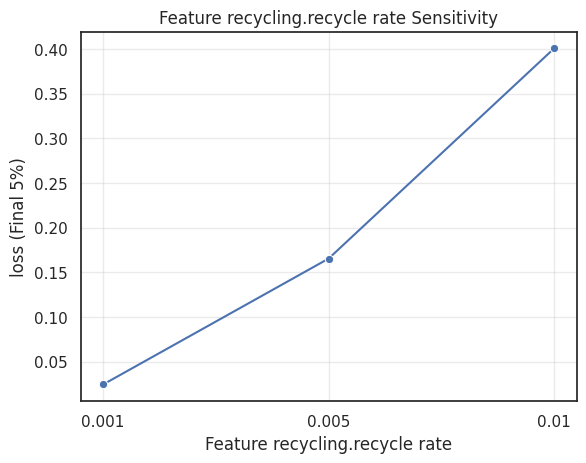

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


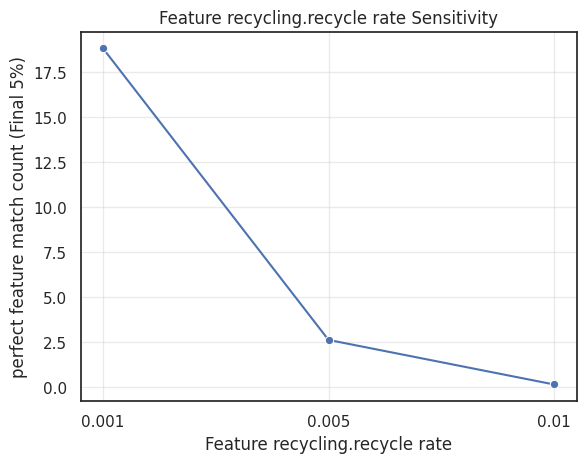

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


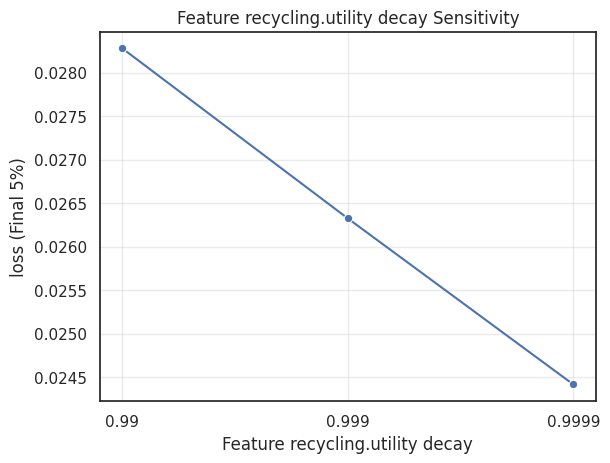

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


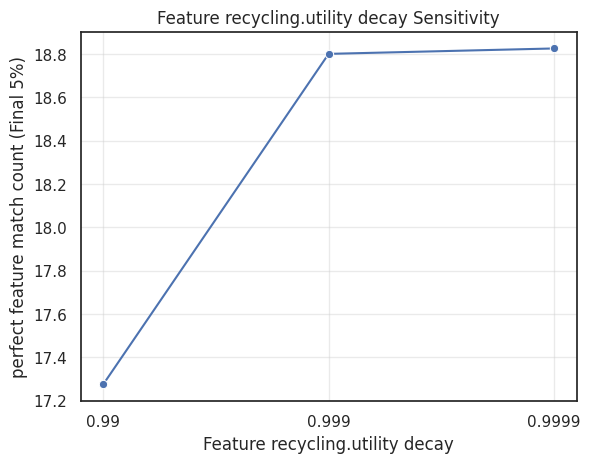

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


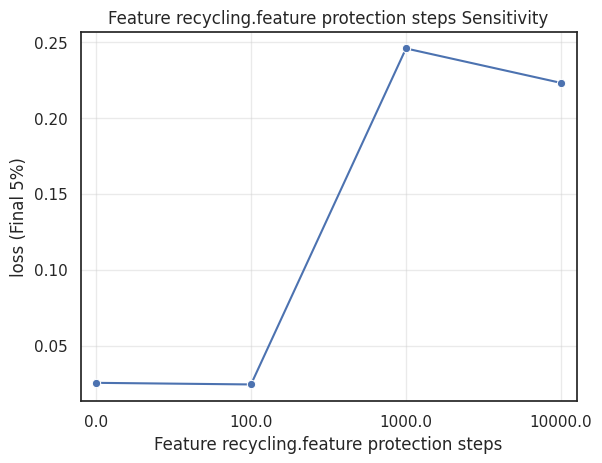

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


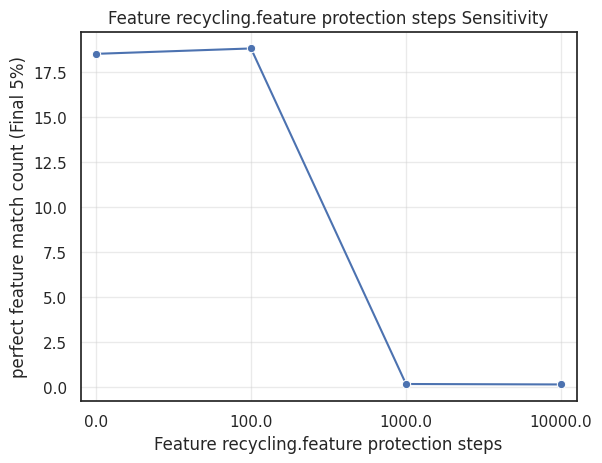

In [19]:
default_hyperparams = {
    'optimizer|learning_rate': 2**-14,
    'optimizer|meta_learning_rate': 2**-5,
    'feature_recycling.recycle_rate': 0.001,
    'feature_recycling.utility_decay': 0.9999,
    'feature_recycling.feature_protection_steps': 100.0,
}

for param_name, param_value in default_hyperparams.items():
    selected_run_df, selected_config_df = select_experiment_runs(
        run_df = run_dfs['maturity_threshold_hyper_sweep'],
        config_df = config_dfs['maturity_threshold_hyper_sweep'],
        chosen_values = {
            k: v for k, v in default_hyperparams.items()
            if k != param_name
        },
    )
    
    param_label = param_name.replace('|', ' ').replace('_', ' ').capitalize()
    
    for metric_col, metric_name in [('loss', 'loss'), ('feature_match/perfect_match_count', 'perfect feature match count')]:
        plot_param_sensitivity(
                run_df = selected_run_df,
                config_df = selected_config_df,
                x_col = param_name,
                title = f'{param_label} Sensitivity',
                x_label = param_label,
                y_label = metric_name,
                metric_col = metric_col,
                metric_type = 'final_avg', # {'cumulative', 'final_avg', 'last'}
                step_col = 'step',
                legend_title = None,
                show_ci = False,
                baseline_col = None,
                pow_2_x_axis = 'learning_rate' in param_name,
                pow_2_legend = True,
            )
        plt.show()

## With Maturity Threshold v2

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


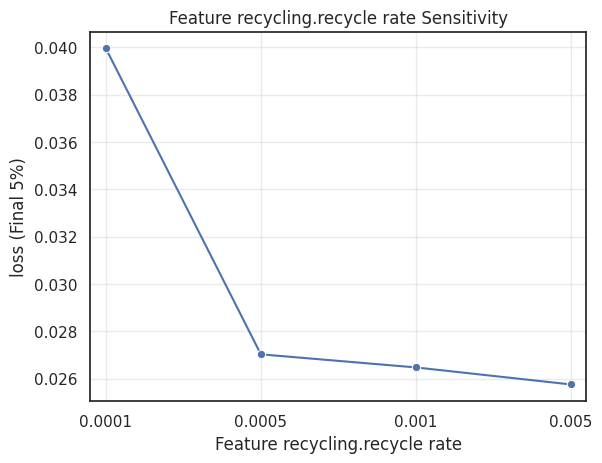

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


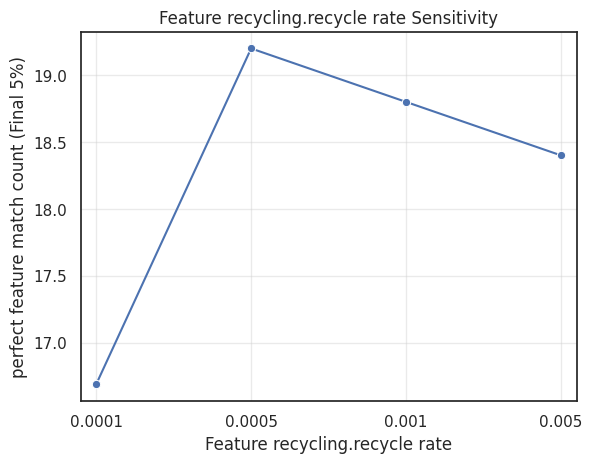

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


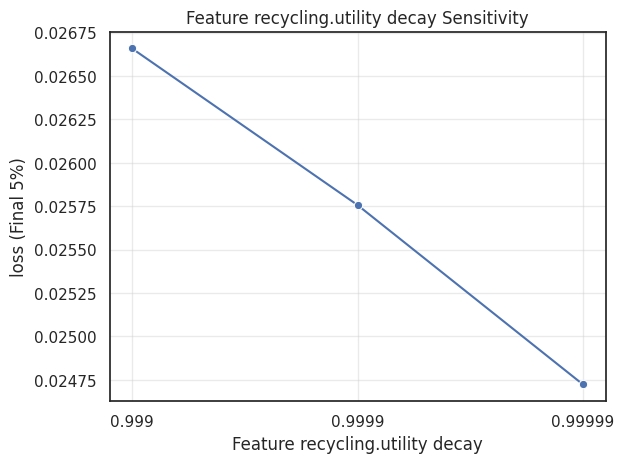

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


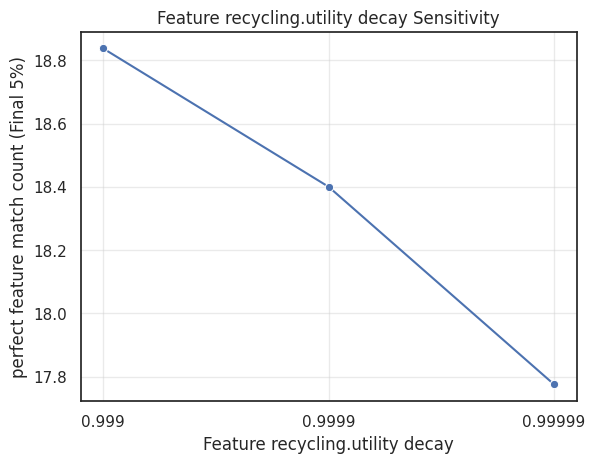

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


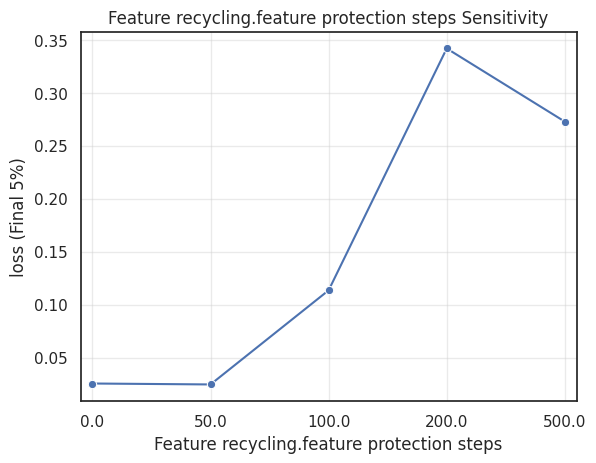

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


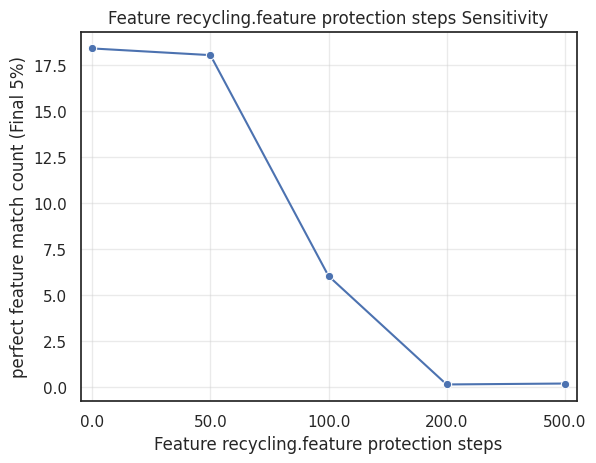

In [ ]:
default_hyperparams = {
    'feature_recycling.recycle_rate': 0.005,
    'feature_recycling.utility_decay': 0.9999,
    'feature_recycling.feature_protection_steps': 0.0,
}

for param_name, param_value in default_hyperparams.items():
    selected_run_df, selected_config_df = select_experiment_runs(
        run_df = run_dfs['maturity_threshold_hyper_sweep_v2'],
        config_df = config_dfs['maturity_threshold_hyper_sweep_v2'],
        chosen_values = {
            k: v for k, v in default_hyperparams.items()
            if k != param_name
        },
    )
    
    param_label = param_name.replace('|', ' ').replace('_', ' ').capitalize()
    
    for metric_col, metric_name in [('loss', 'loss'), ('feature_match/perfect_match_count', 'perfect feature match count')]:
        plot_param_sensitivity(
                run_df = selected_run_df,
                config_df = selected_config_df,
                x_col = param_name,
                title = f'{param_label} Sensitivity',
                x_label = param_label,
                y_label = metric_name,
                metric_col = metric_col,
                metric_type = 'final_avg', # {'cumulative', 'final_avg', 'last'}
                step_col = 'step',
                legend_title = None,
                show_ci = False,
                baseline_col = None,
                pow_2_x_axis = 'learning_rate' in param_name,
                pow_2_legend = True,
            )
        plt.show()

## Adaptive Initial Step-Size

Text(0.5, 1.0, 'Autostep + Feature Search Feature Matches')

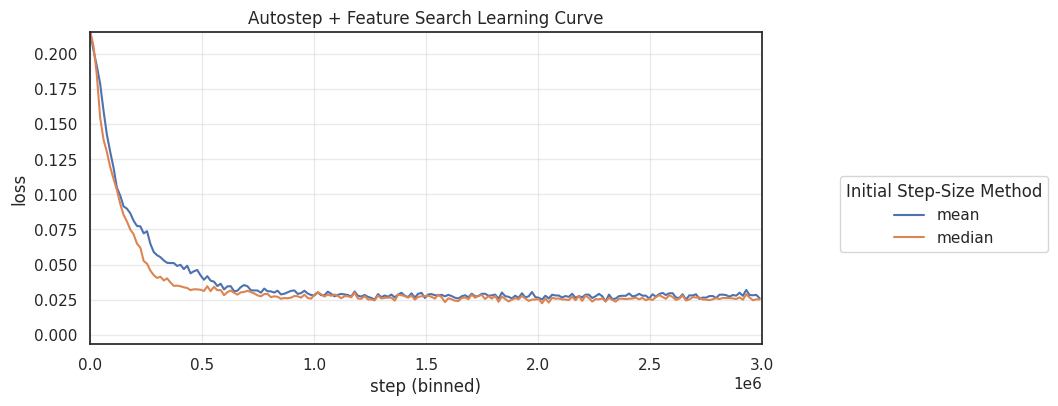

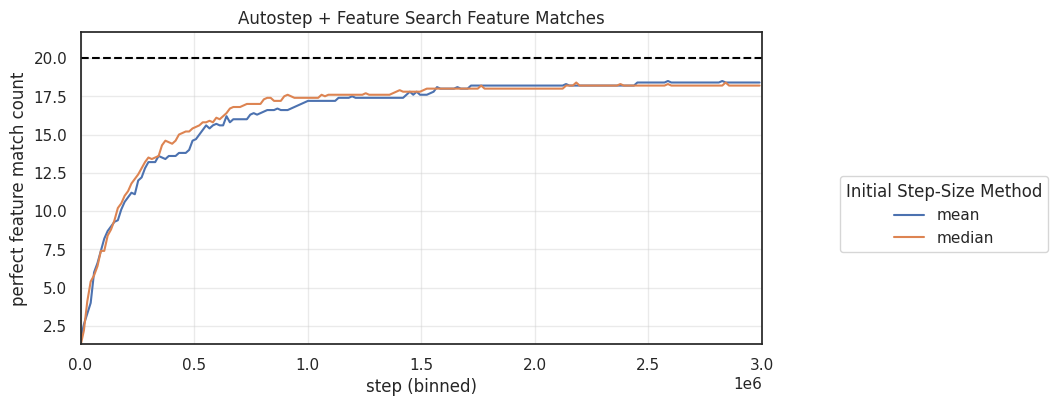

In [8]:
best_hyperparams = {
    'feature_recycling.recycle_rate': 0.001,
    'feature_recycling.utility_decay': 0.999,
}
selected_run_df, selected_config_df = select_experiment_runs(
    run_df = run_dfs['adaptive_init_lr_hyper_sweep'],
    config_df = config_dfs['adaptive_init_lr_hyper_sweep'],
    chosen_values = best_hyperparams,
)

# selected_run_df, selected_config_df = best_run_dfs['maturity_threshold_hyper_sweep_v2'], best_config_dfs['maturity_threshold_hyper_sweep_v2']

plot_learning_curves(
    run_df = selected_run_df,
    config_df = selected_config_df,
    n_bins = 200,
    figsize = (8, 4),
    hue_col = 'feature_recycling|initial_step_size_method',
    legend_title = 'Initial Step-Size Method',
)
plt.title('Autostep + Feature Search Learning Curve')

plot_learning_curves(
    run_df = selected_run_df,
    config_df = selected_config_df,
    y_col = 'feature_match/perfect_match_count',
    y_label = 'perfect feature match count',
    hue_col = 'feature_recycling|initial_step_size_method',
    legend_title = 'Initial Step-Size Method',
    n_bins = 200,
    figsize = (8, 4),
)
plt.axhline(20, color='black', linestyle='--')

plt.title('Autostep + Feature Search Feature Matches')

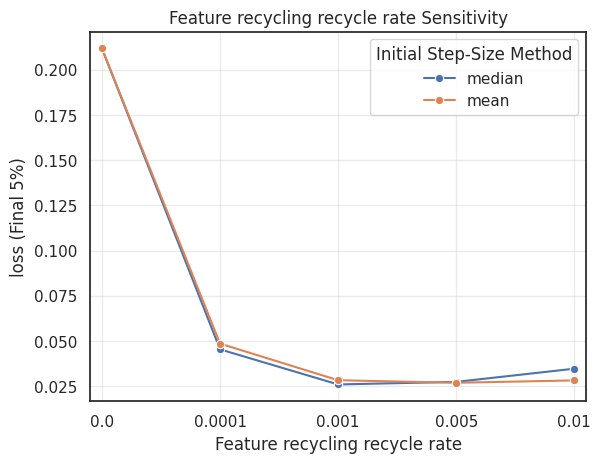

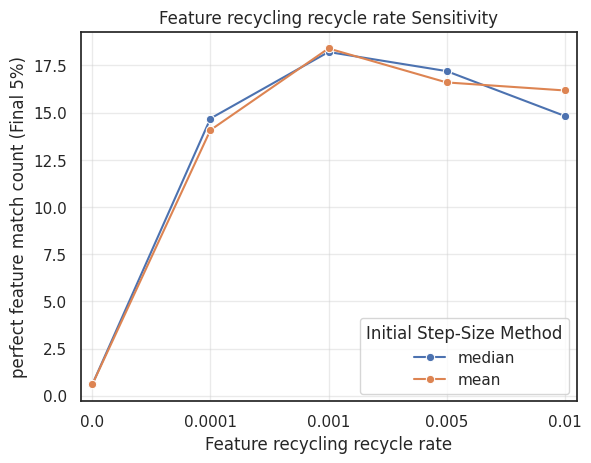

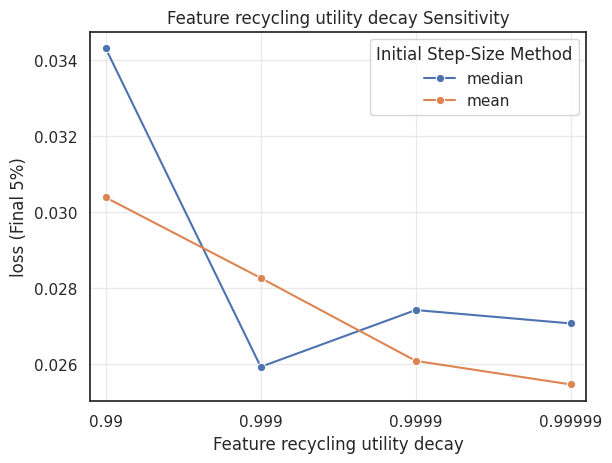

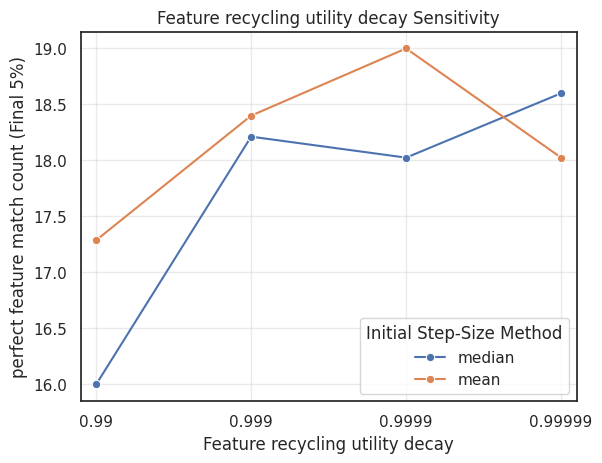

In [17]:
default_hyperparams = {
    'feature_recycling.recycle_rate': 0.001,
    'feature_recycling.utility_decay': 0.999,
}
for param_name, param_value in default_hyperparams.items():
    selected_run_df, selected_config_df = select_experiment_runs(
        run_df = run_dfs['adaptive_init_lr_hyper_sweep'],
        config_df = config_dfs['adaptive_init_lr_hyper_sweep'],
        chosen_values = {
            k: v for k, v in default_hyperparams.items()
            if k != param_name
        },
    )
    
    param_label = param_name.replace('.', ' ').replace('_', ' ').capitalize()
    
    for metric_col, metric_name in [('loss', 'loss'), ('feature_match/perfect_match_count', 'perfect feature match count')]:
        plot_param_sensitivity(
                run_df = selected_run_df,
                config_df = selected_config_df,
                x_col = param_name,
                title = f'{param_label} Sensitivity',
                x_label = param_label,
                y_label = metric_name,
                metric_col = metric_col,
                metric_type = 'final_avg', # {'cumulative', 'final_avg', 'last'}
                step_col = 'step',
                show_ci = False,
                baseline_col = None,
                hue_col = 'feature_recycling|initial_step_size_method',
                legend_title = 'Initial Step-Size Method',
                pow_2_x_axis = 'learning_rate' in param_name,
            )
        plt.show()

## Scaling Learner Hidden Dimension

/tmp/ipykernel_14467/3254671272.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_config_dfs['scaling_hyper_sweep']['model.hidden_dim'] = best_config_dfs['scaling_hyper_sweep']['model|hidden_dim'].astype(int)


[ 1000  5000 10000 20000 50000]
[ 1000  5000 10000 20000 50000]


Text(0.5, 1.0, 'Autostep + Feature Search Feature Matches')

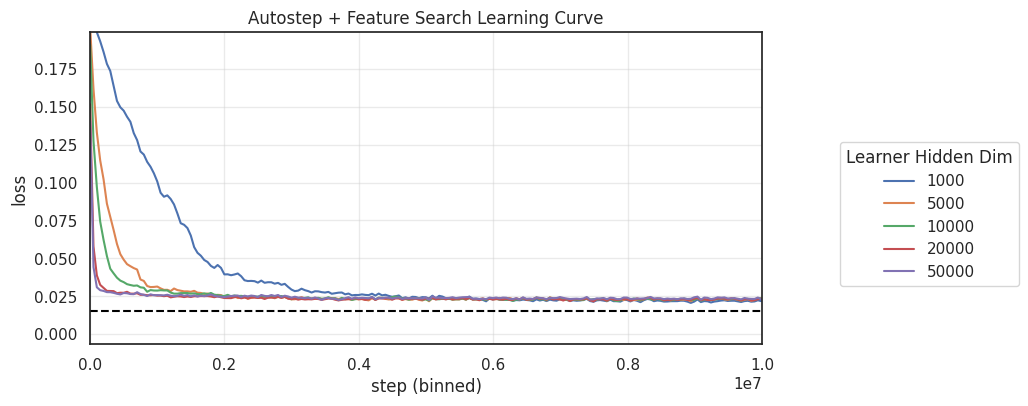

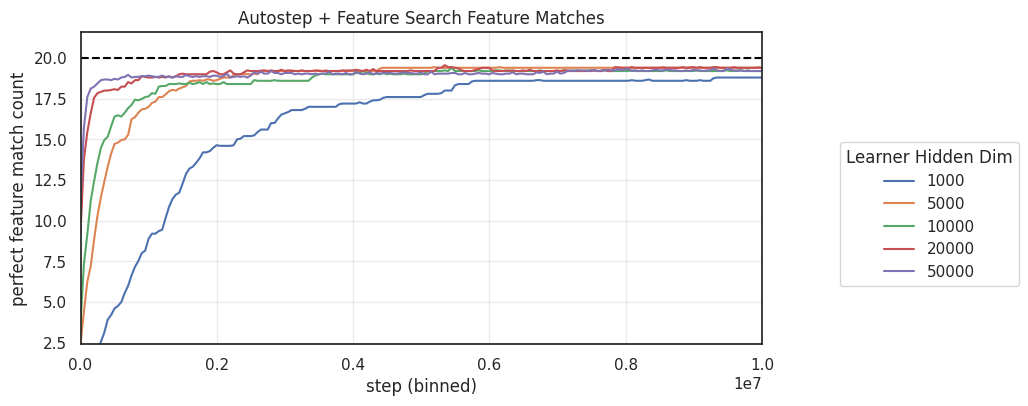

In [44]:
# Compute baseline as average loss over last 5% of steps for perfect_features_baseline_sweep
run_df = best_run_dfs['perfect_features_baseline_sweep']
total_steps = run_df['step'].max()
last_5_percent_steps = run_df[run_df['step'] >= total_steps * 0.95]
baseline_loss = last_5_percent_steps['loss'].mean()

best_config_dfs['scaling_hyper_sweep']['model.hidden_dim'] = best_config_dfs['scaling_hyper_sweep']['model|hidden_dim'].astype(int)

# Plot learning curve
plot_learning_curves(
    run_df = best_run_dfs['scaling_hyper_sweep'],
    config_df = best_config_dfs['scaling_hyper_sweep'],
    n_bins = 200,
    figsize = (8, 4),
    hue_col = 'model.hidden_dim',
    legend_title = 'Learner Hidden Dim',
)
plt.axhline(baseline_loss, color='black', linestyle='--')
plt.title('Autostep + Feature Search Learning Curve')

# Plot feature matches
plot_learning_curves(
    run_df = best_run_dfs['scaling_hyper_sweep'],
    config_df = best_config_dfs['scaling_hyper_sweep'],
    y_col = 'feature_match/perfect_match_count',
    y_label = 'perfect feature match count',
    hue_col = 'model.hidden_dim',
    legend_title = 'Learner Hidden Dim',
    n_bins = 200,
    figsize = (8, 4),
)
plt.axhline(20, color='black', linestyle='--')
plt.title('Autostep + Feature Search Feature Matches')

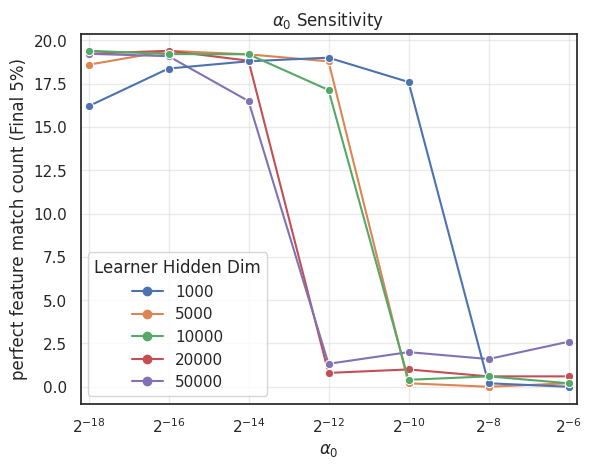

In [ ]:
plot_param_sensitivity(
    run_df = run_dfs['scaling_hyper_sweep'],
    config_df = config_dfs['scaling_hyper_sweep'],
    x_col = 'optimizer|learning_rate',
    title = f'$\\alpha_0$ Sensitivity',
    x_label = '$\\alpha_0$',
    y_label = 'perfect feature match count',
    metric_col = 'feature_match/perfect_match_count',
    metric_type = 'final_avg', # {'cumulative', 'final_avg', 'last'}
    step_col = 'step',
    show_ci = False,
    baseline_col = None,
    hue_col = 'model.hidden_dim',
    legend_title = 'Learner Hidden Dim',
    pow_2_x_axis = True,
)
plt.show()

## Weight Decay

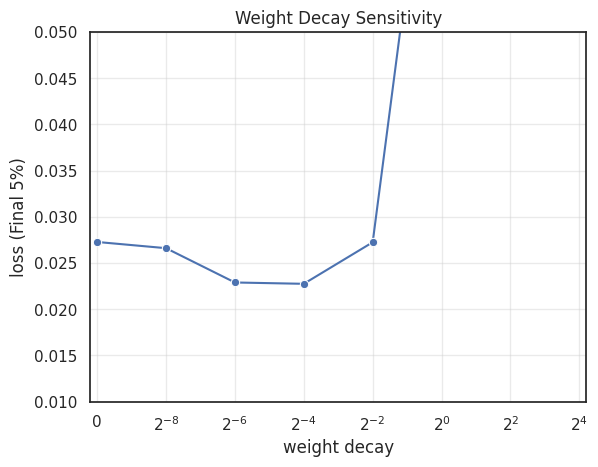

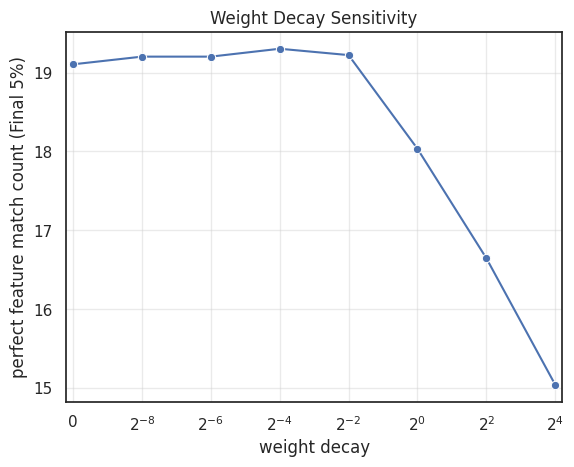

In [ ]:
plot_param_sensitivity(
    run_df = run_dfs['weight_decay_sweep'],
    config_df = config_dfs['weight_decay_sweep'],
    x_col = 'optimizer|weight_decay',
    title = f'Weight Decay Sensitivity',
    x_label = 'weight decay',
    y_label = 'loss',
    metric_col = 'loss',
    metric_type = 'final_avg', # {'cumulative', 'final_avg', 'last'}
    step_col = 'step',
    show_ci = False,
    baseline_col = None,
    pow_2_x_axis = True,
)
plt.ylim(0.01, 0.05)
plt.show()

plot_param_sensitivity(
    run_df = run_dfs['weight_decay_sweep'],
    config_df = config_dfs['weight_decay_sweep'],
    x_col = 'optimizer|weight_decay',
    title = f'Weight Decay Sensitivity',
    x_label = 'weight decay',
    y_label = 'perfect feature match count',
    metric_col = 'feature_match/perfect_match_count',
    metric_type = 'final_avg', # {'cumulative', 'final_avg', 'last'}
    step_col = 'step',
    show_ci = False,
    baseline_col = None,
    pow_2_x_axis = True,
)
plt.show()

## New Standard Method Sweep

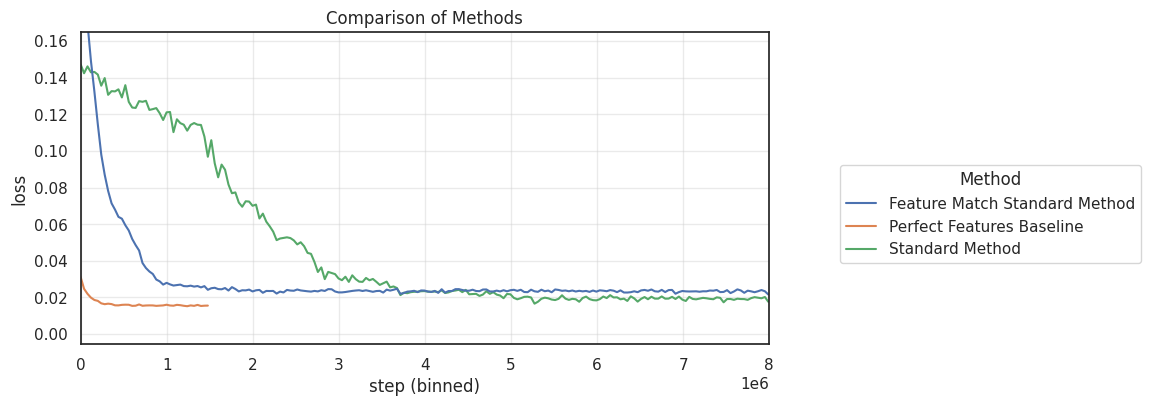

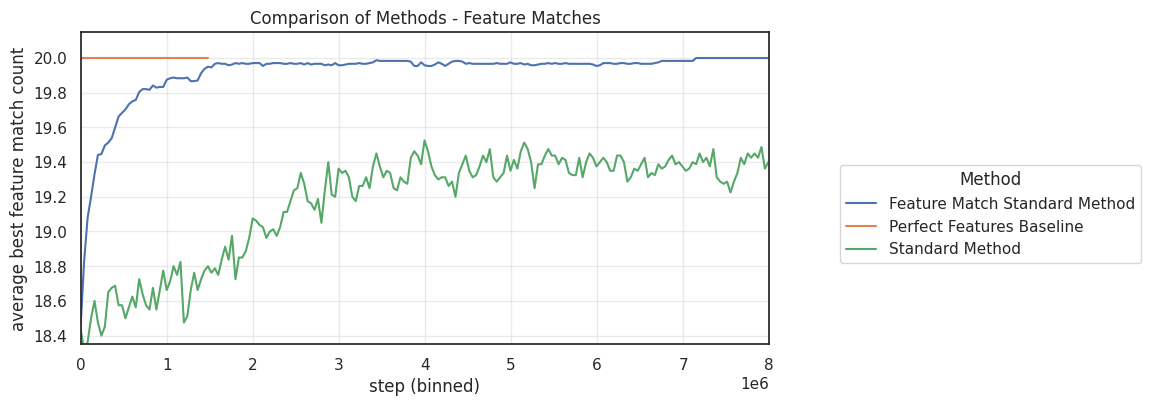

In [ ]:
plot_config_dfs = [
    best_config_dfs['perfect_features_baseline_sweep'],
    best_config_dfs['baseline_hyper_sweep'],
    best_feat_config_dfs['baseline_hyper_sweep'],
]
plot_run_dfs = [
    best_run_dfs['perfect_features_baseline_sweep'],
    best_run_dfs['baseline_hyper_sweep'],
    best_feat_run_dfs['baseline_hyper_sweep'],
]

plot_config_dfs[0].loc[:, 'method'] = 'Perfect Features Baseline'
plot_config_dfs[1].loc[:, 'method'] = 'Standard Method'
plot_config_dfs[2].loc[:, 'method'] = 'Feature Match Standard Method'

# First merge each config df with the corresponding run df, then concat all of those

merged_df_list = [
    run_df.merge(config_df, on='run_id', how='left')
    for run_df, config_df in zip(plot_run_dfs, plot_config_dfs)
]
all_weight_decay_merged_df = pd.concat(merged_df_list, ignore_index=True)

# Plot curves for loss and feature matches for all 4 methods in two plots

plot_learning_curves(
    run_df = all_weight_decay_merged_df,
    n_bins = 200,
    figsize = (8, 4),
    hue_col = 'method',
    legend_title = 'Method',
)
plt.title('Comparison of Methods')
plt.show()

plot_learning_curves(
    run_df = all_weight_decay_merged_df,
    n_bins = 200,
    figsize = (8, 4),
    y_col = 'feature_match/average_best_match_count',
    y_label = 'average best feature match count',
    hue_col = 'method',
    legend_title = 'Method',
)
plt.title('Comparison of Methods - Feature Matches')
plt.show()